## **Agrupamiento final**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [3]:
USUARIO = "postgres"
PASSWORD = "1028"
HOST = "localhost"
PUERTO = "5432"
BASE_DATOS = "dw_analisis_criminalidad"

engine = create_engine(
    f"postgresql+psycopg2://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}"
)

print("Conexión creada correctamente.")

Conexión creada correctamente.


#### **Calculo de variables iniciales**

##### **Distribucion de armas**

In [4]:
query = """
WITH afectaciones_municipales AS (
    SELECT
        u.municipio,
        a.id_arma,
        a.nombre_arma,
        SUM(f.cantidad_delitos) AS afectaciones
    FROM fact_delitos f
    JOIN dim_ubicacion u
        ON f.id_ubicacion = u.id_ubicacion
    JOIN dim_tiempo t
        ON f.id_tiempo = t.id_tiempo
    JOIN dim_arma a
        ON f.id_arma = a.id_arma
    WHERE t.anio BETWEEN 2014 AND 2024
    GROUP BY
        u.municipio,
        a.id_arma,
        a.nombre_arma
),
totales_municipales AS (
    SELECT
        municipio,
        SUM(afectaciones) AS total_municipal
    FROM afectaciones_municipales
    GROUP BY municipio
),
participaciones AS (
    SELECT
        am.municipio,
        am.id_arma,
        am.nombre_arma,
        am.afectaciones,
        100.0 * am.afectaciones
            / NULLIF(tm.total_municipal, 0) AS pct_municipal
    FROM afectaciones_municipales am
    JOIN totales_municipales tm
        ON am.municipio = tm.municipio
),
matriz_completa AS (
    SELECT
        m.municipio,
        a.id_arma,
        a.nombre_arma,
        COALESCE(p.afectaciones, 0) AS afectaciones,
        COALESCE(p.pct_municipal, 0) AS pct_municipal
    FROM (
        SELECT DISTINCT municipio
        FROM dim_ubicacion
    ) m
    CROSS JOIN dim_arma a
    LEFT JOIN participaciones p
        ON p.municipio = m.municipio
       AND p.id_arma = a.id_arma
)
SELECT
    nombre_arma,
    SUM(afectaciones) AS total_departamental,
    ROUND(
        100.0 * SUM(afectaciones)
        / NULLIF(SUM(SUM(afectaciones)) OVER (), 0),
        2
    ) AS pct_departamental,
    ROUND(AVG(pct_municipal)::numeric, 2)
        AS promedio_pct_municipal,
    ROUND(STDDEV_POP(pct_municipal)::numeric, 2)
        AS desviacion_pct_municipal,
    ROUND(
        (PERCENTILE_CONT(0.75)
            WITHIN GROUP (ORDER BY pct_municipal)
         - PERCENTILE_CONT(0.25)
            WITHIN GROUP (ORDER BY pct_municipal))::numeric,
        2
    ) AS rango_intercuartil_pct,
    ROUND(MIN(pct_municipal)::numeric, 2) AS minimo_pct,
    ROUND(MAX(pct_municipal)::numeric, 2) AS maximo_pct,
    COUNT(*) FILTER (WHERE afectaciones > 0)
        AS municipios_con_registros,
    ROUND(
        100.0 * COUNT(*) FILTER (WHERE afectaciones > 0)
        / NULLIF(COUNT(*), 0),
        2
    ) AS pct_municipios_con_registros
FROM matriz_completa
GROUP BY id_arma, nombre_arma
ORDER BY desviacion_pct_municipal DESC;
"""
df_armas = pd.read_sql(query, engine)
df_armas


,nombre_arma,total_departamental,pct_departamental,promedio_pct_municipal,desviacion_pct_municipal,rango_intercuartil_pct,minimo_pct,maximo_pct,municipios_con_registros,pct_municipios_con_registros
0,CONTUNDENTES,139493.0,23.03,23.76,6.08,7.81,5.43,39.38,125,100.0
1,ARMA DE FUEGO,57591.0,9.51,11.50,5.99,6.63,3.03,36.41,125,100.0
2,SIN EMPLEO DE ARMAS,248516.0,41.04,36.35,5.30,7.43,26.77,51.52,125,100.0
3,No reportado,22141.0,3.66,5.31,4.05,2.18,0.00,26.36,124,99.2
4,ACIDO,8971.0,1.48,5.67,3.62,4.10,0.00,15.15,113,90.4
5,VEHICULO,23893.0,3.95,2.68,3.04,3.49,0.00,15.46,115,92.0
6,ARMA BLANCA / CORTOPUNZANTE,52841.0,8.73,9.67,2.94,4.04,4.77,21.62,125,100.0
7,LLAVE MAESTRA,31284.0,5.17,1.26,1.35,1.11,0.00,7.24,112,89.6
8,MOTO,11459.0,1.89,1.36,1.31,1.41,0.00,5.97,112,89.6
9,PALANCAS,5528.0,0.91,1.48,0.95,1.03,0.00,6.11,120,96.0


##### **Matriz de variables**

In [5]:
query = """
WITH datos_base AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        t.anio,
        d.tipo_delito,
        v.genero,
        v.grupo_etario,
        a.nombre_arma,
        f.cantidad_delitos
    FROM fact_delitos f
    INNER JOIN dim_ubicacion u
        ON f.id_ubicacion = u.id_ubicacion
    INNER JOIN dim_tiempo t
        ON f.id_tiempo = t.id_tiempo
    INNER JOIN dim_delito d
        ON f.id_delito = d.id_delito
    INNER JOIN dim_victima v
        ON f.id_victima = v.id_victima
    INNER JOIN dim_arma a
        ON f.id_arma = a.id_arma
),

magnitud AS (
    SELECT
        id_ubicacion,
        municipio,
        SUM(cantidad_delitos) AS total_afectaciones
    FROM datos_base
    GROUP BY id_ubicacion, municipio
),

afectaciones_anuales AS (
    SELECT
        id_ubicacion,
        municipio,
        anio,
        SUM(cantidad_delitos) AS afectaciones_anuales
    FROM datos_base
    GROUP BY id_ubicacion, municipio, anio
),

tendencia AS (
    SELECT
        id_ubicacion,
        REGR_SLOPE(afectaciones_anuales, anio) AS tendencia_anual
    FROM afectaciones_anuales
    GROUP BY id_ubicacion
),

delitos AS (
    SELECT
        id_ubicacion,
        municipio,

        SUM(CASE
            WHEN tipo_delito = 'Amenazas'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_amenazas,

        SUM(CASE
            WHEN tipo_delito = 'Delitos sexuales'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_delitos_sexuales,

        SUM(CASE
            WHEN tipo_delito = 'Homicidio'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_homicidios,

        SUM(CASE
            WHEN tipo_delito = 'Hurto de motocicletas y automotores'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_hurto_motocicletas_automotores,

        SUM(CASE
            WHEN tipo_delito = 'Hurto a residencias y entidades comerciales'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_hurto_residencias_comerciales,

        SUM(CASE
            WHEN tipo_delito = 'Lesiones personales'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_lesiones_personales,

        SUM(CASE
            WHEN tipo_delito = 'Violencia intrafamiliar'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_violencia_intrafamiliar

    FROM datos_base
    GROUP BY id_ubicacion, municipio
),
genero AS (
    SELECT
        id_ubicacion,

        SUM(CASE
            WHEN LOWER(genero) = 'masculino'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_masculino,

        SUM(CASE
            WHEN LOWER(genero) = 'femenino'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_femenino
    FROM datos_base
    GROUP BY id_ubicacion
),

edad AS (
    SELECT
        id_ubicacion,

        SUM(CASE
            WHEN grupo_etario = 'Adolescentes'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_edad_adolescentes,

        SUM(CASE
            WHEN grupo_etario = 'Menores'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_edad_menores,

        SUM(CASE
            WHEN grupo_etario = 'Adultos'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_edad_adultos
    FROM datos_base
    GROUP BY id_ubicacion
),

armas AS (
    SELECT
        id_ubicacion,

        SUM(CASE
            WHEN nombre_arma = 'SIN EMPLEO DE ARMAS'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_sin_empleo_armas,

        SUM(CASE
            WHEN nombre_arma = 'CONTUNDENTES'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_armas_contundentes,

        SUM(CASE
            WHEN nombre_arma = 'ARMA DE FUEGO'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_arma_fuego,

        SUM(CASE
            WHEN nombre_arma = 'ARMA BLANCA / CORTOPUNZANTE'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_arma_blanca,

        SUM(CASE
            WHEN nombre_arma = 'LLAVE MAESTRA'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_llave_maestra,

        SUM(CASE
            WHEN nombre_arma = 'ACIDO'
            THEN cantidad_delitos ELSE 0
        END) * 100.0 / SUM(cantidad_delitos)
        AS pct_acido
        

    FROM datos_base
    GROUP BY id_ubicacion
)

SELECT
    m.id_ubicacion,
    m.municipio,

    d.pct_amenazas,
    d.pct_delitos_sexuales,
    d.pct_homicidios,
    d.pct_hurto_motocicletas_automotores,
    d.pct_hurto_residencias_comerciales,
    d.pct_lesiones_personales,
    d.pct_violencia_intrafamiliar,

    t.tendencia_anual,

    g.pct_masculino,
    g.pct_femenino,

    e.pct_edad_adolescentes,
    e.pct_edad_menores,
    e.pct_edad_adultos,

    a.pct_sin_empleo_armas,
    a.pct_armas_contundentes,
    a.pct_arma_fuego,
    a.pct_arma_blanca,
    a.pct_llave_maestra,
    a.pct_acido

FROM magnitud m

LEFT JOIN tendencia t
    ON m.id_ubicacion = t.id_ubicacion

LEFT JOIN delitos d
    ON m.id_ubicacion = d.id_ubicacion

LEFT JOIN genero g
    ON m.id_ubicacion = g.id_ubicacion

LEFT JOIN edad e
    ON m.id_ubicacion = e.id_ubicacion

LEFT JOIN armas a
    ON m.id_ubicacion = a.id_ubicacion

ORDER BY m.municipio;
"""

with engine.connect() as conn:
    df_matriz_variables = pd.read_sql(query, conn)

df_matriz_variables.head(20)

,id_ubicacion,municipio,pct_amenazas,pct_delitos_sexuales,pct_homicidios,pct_hurto_motocicletas_automotores,pct_hurto_residencias_comerciales,pct_lesiones_personales,pct_violencia_intrafamiliar,tendencia_anual,...,pct_femenino,pct_edad_adolescentes,pct_edad_menores,pct_edad_adultos,pct_sin_empleo_armas,pct_armas_contundentes,pct_arma_fuego,pct_arma_blanca,pct_llave_maestra,pct_acido
0,1,Abejorral,5.965909,13.446970,5.681818,3.977273,11.174242,41.950758,17.803030,7.818182,...,39.299242,5.113636,3.503788,89.299242,31.250000,26.420455,8.712121,15.435606,0.378788,7.670455
1,2,Abriaquí,18.181818,33.333333,3.030303,3.030303,9.090909,15.151515,18.181818,-0.409766,...,54.545455,12.121212,9.090909,78.787879,51.515152,33.333333,3.030303,12.121212,0.000000,0.000000
2,3,Alejandría,5.949008,10.764873,2.266289,3.116147,6.798867,43.909348,27.195467,3.809091,...,49.575071,5.099150,3.399433,90.084986,36.827195,39.376771,3.682720,9.631728,0.283286,3.966006
3,4,Amagá,9.585179,8.296416,5.678615,7.128474,7.974225,42.368103,18.968989,7.827273,...,47.080145,5.396698,2.577527,90.213451,33.749497,26.862666,8.860250,10.229561,0.845751,9.625453
4,5,Amalfi,9.890110,9.134615,10.714286,7.486264,7.486264,37.843407,17.445055,-0.663636,...,47.733516,3.434066,2.335165,93.681319,31.112637,25.892857,14.835165,8.653846,0.549451,9.890110
5,6,Andes,7.147042,10.105448,10.632689,4.920914,5.418864,35.559461,26.215583,0.790909,...,48.681898,5.330990,2.665495,90.861160,31.546573,27.211482,11.892209,12.214411,0.644405,8.230814
6,7,Angelópolis,8.318264,11.392405,7.775769,3.435805,5.605787,25.497288,37.974684,2.036364,...,51.717902,5.063291,3.435805,90.958409,36.528029,29.475588,11.754069,9.584087,0.180832,4.159132
7,8,Angostura,13.019391,9.279778,11.911357,5.124654,6.232687,32.271468,22.160665,-1.727273,...,45.013850,6.371191,3.878116,87.811634,28.808864,24.930748,16.620499,12.603878,0.692521,7.202216
8,9,Anorí,10.683425,9.033778,16.339356,3.063629,7.541241,35.506677,17.831893,8.063636,...,46.975648,4.163394,2.827965,92.144540,31.893166,23.959152,17.360566,9.583661,0.628437,8.483896
9,10,Anza,12.777778,10.833333,9.166667,3.888889,7.500000,36.388889,19.444444,0.845455,...,51.388889,4.166667,6.111111,88.611111,36.111111,19.166667,11.388889,14.722222,0.555556,8.333333


#### **Correlacion entre variables**

In [6]:
corr = df_matriz_variables.drop(columns=['id_ubicacion', 'municipio', 'tendencia_anual']).corr()

corr_fuertes = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

corr_fuertes.columns = ['variable_1', 'variable_2', 'correlacion']

corr_fuertes = (
    corr_fuertes
    .assign(abs_corr=lambda x: x['correlacion'].abs())
    .query('abs_corr >= 0.70')
    .sort_values('abs_corr', ascending=False)
)

corr_fuertes

,variable_1,variable_2,correlacion,abs_corr
44,pct_homicidios,pct_arma_fuego,0.929110,0.929110
118,pct_edad_adolescentes,pct_edad_adultos,-0.825910,0.825910
60,pct_hurto_motocicletas_automotores,pct_llave_maestra,0.822387,0.822387
125,pct_edad_menores,pct_edad_adultos,-0.817948,0.817948
98,pct_masculino,pct_femenino,-0.755091,0.755091


In [7]:
variables_pendientes = [
    "pct_amenazas",
    "pct_delitos_sexuales",
    "pct_hurto_residencias_comerciales",
    "pct_lesiones_personales",
    "pct_violencia_intrafamiliar",
    "pct_sin_empleo_armas",
    "pct_armas_contundentes",
    "pct_arma_blanca",
    "pct_acido"
]

resumen = df_matriz_variables[variables_pendientes].agg(
    ["min", "max", "mean", "std", "nunique"]
).T

resumen["ceros"] = (
    df_matriz_variables[variables_pendientes].eq(0).sum()
)

resumen["faltantes"] = (
    df_matriz_variables[variables_pendientes].isna().sum()
)

print(resumen.round(4))

                                       min      max     mean     std  nunique  \
pct_amenazas                        2.6915  33.3333   9.4737  4.9027    125.0   
pct_delitos_sexuales                4.2570  33.3333  10.3891  4.2431    124.0   
pct_hurto_residencias_comerciales   3.2000  21.5385   9.5407  3.6398    125.0   
pct_lesiones_personales            15.1515  52.6814  34.8781  7.3382    125.0   
pct_violencia_intrafamiliar         8.9139  37.9747  19.7064  5.6496    125.0   
pct_sin_empleo_armas               26.7677  51.5152  36.3454  5.3238    124.0   
pct_armas_contundentes              5.4264  39.3768  23.7603  6.1022    125.0   
pct_arma_blanca                     4.7697  21.6216   9.6706  2.9520    125.0   
pct_acido                           0.0000  15.1473   5.6714  3.6337    113.0   

                                   ceros  faltantes  
pct_amenazas                           0          0  
pct_delitos_sexuales                   0          0  
pct_hurto_residencias_comer

#### **Seleccion de variables**

In [12]:
variables_nuevas = [
    # Magnitud
    #'tendencia_anual',

    # Composición delictiva
    'pct_amenazas',
    'pct_delitos_sexuales',
    'pct_homicidios',
    'pct_hurto_motocicletas_automotores',
    'pct_hurto_residencias_comerciales',
    'pct_lesiones_personales',
    'pct_violencia_intrafamiliar',
    
    # Género
    'pct_masculino',

    # Edad
    'pct_edad_adolescentes',
    'pct_edad_menores',

    # Armas
    'pct_sin_empleo_armas',
    'pct_armas_contundentes',
    'pct_arma_fuego',
    'pct_arma_blanca',
    'pct_llave_maestra',
    'pct_acido'
]

len(variables_nuevas)

16

##### **Validacion de calidad**

In [13]:
import numpy as np

# Seleccionar las variables definitivas
X_nuevo = df_matriz_variables[variables_nuevas].copy()

# Verificar dimensiones
print("Dimensiones:", X_nuevo.shape)

# Verificar valores faltantes
print("Valores faltantes:", X_nuevo.isna().sum().sum())

# Verificar valores infinitos
print(
    "Valores infinitos:",
    np.isinf(X_nuevo.select_dtypes(include="number")).sum().sum()
)

# Verificar columnas sin variabilidad
print(
    "Variables constantes:",
    X_nuevo.columns[X_nuevo.nunique() <= 1].tolist()
)

Dimensiones: (125, 16)
Valores faltantes: 0
Valores infinitos: 0
Variables constantes: []


In [14]:
X_nuevo = df_matriz_variables[variables_nuevas].copy()

X_nuevo.shape

(125, 16)

##### **Estandarizacion**

In [15]:
from sklearn.preprocessing import StandardScaler

scaler_nuevo = StandardScaler()

X_nuevo_estandarizado = scaler_nuevo.fit_transform(X_nuevo)

df_X_nuevo_estandarizado = pd.DataFrame(
    X_nuevo_estandarizado,
    columns=variables_nuevas,
    index=df_matriz_variables.index
)

df_X_nuevo_estandarizado.head()

,pct_amenazas,pct_delitos_sexuales,pct_homicidios,pct_hurto_motocicletas_automotores,pct_hurto_residencias_comerciales,pct_lesiones_personales,pct_violencia_intrafamiliar,pct_masculino,pct_edad_adolescentes,pct_edad_menores,pct_sin_empleo_armas,pct_armas_contundentes,pct_arma_fuego,pct_arma_blanca,pct_llave_maestra,pct_acido
0,-0.718365,0.723583,-0.540413,-0.675620,0.450619,0.967690,-0.338255,0.892181,0.295879,0.179720,-0.960955,0.437697,-0.465109,1.960738,-0.654815,0.552375
1,1.783325,5.429228,-0.979120,-0.882891,-0.124062,-2.699022,-0.270939,-2.124773,4.778929,4.112027,2.860910,1.575112,-1.414326,0.833475,-0.934881,-1.567067
2,-0.721826,0.088927,-1.105529,-0.864102,-0.756315,1.235668,1.330925,-0.446529,0.286611,0.106274,0.090865,2.569474,-1.305332,-0.013228,-0.725427,-0.471210
3,0.022824,-0.495176,-0.540943,0.014109,-0.432096,1.024792,-0.131046,-0.266040,0.476965,-0.472197,-0.489567,0.510456,-0.440362,0.190102,-0.309555,1.092565
4,0.085270,-0.296835,0.292233,0.092421,-0.566699,0.405717,-0.401873,-0.369368,-0.778615,-0.642776,-0.986860,0.350888,0.557821,-0.345817,-0.528632,1.165693


#### **Evaluacion de los k**

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rango_k = range(2, 11)

inercia_nueva = []
silueta_nueva = []

for k in rango_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    etiquetas = kmeans.fit_predict(X_nuevo_estandarizado)
    
    inercia_nueva.append(kmeans.inertia_)
    silueta_nueva.append(
        silhouette_score(X_nuevo_estandarizado, etiquetas)
    )

resultados_k_nuevo = pd.DataFrame({
    'k': list(rango_k),
    'inercia': inercia_nueva,
    'silueta': silueta_nueva
})

resultados_k_nuevo

,k,inercia,silueta
0,2,1677.231524,0.147959
1,3,1481.288833,0.118131
2,4,1289.915919,0.170316
3,5,1168.140744,0.156401
4,6,1067.603183,0.170147
5,7,1001.366511,0.153610
6,8,949.327969,0.147837
7,9,892.948765,0.155378
8,10,853.370224,0.153893


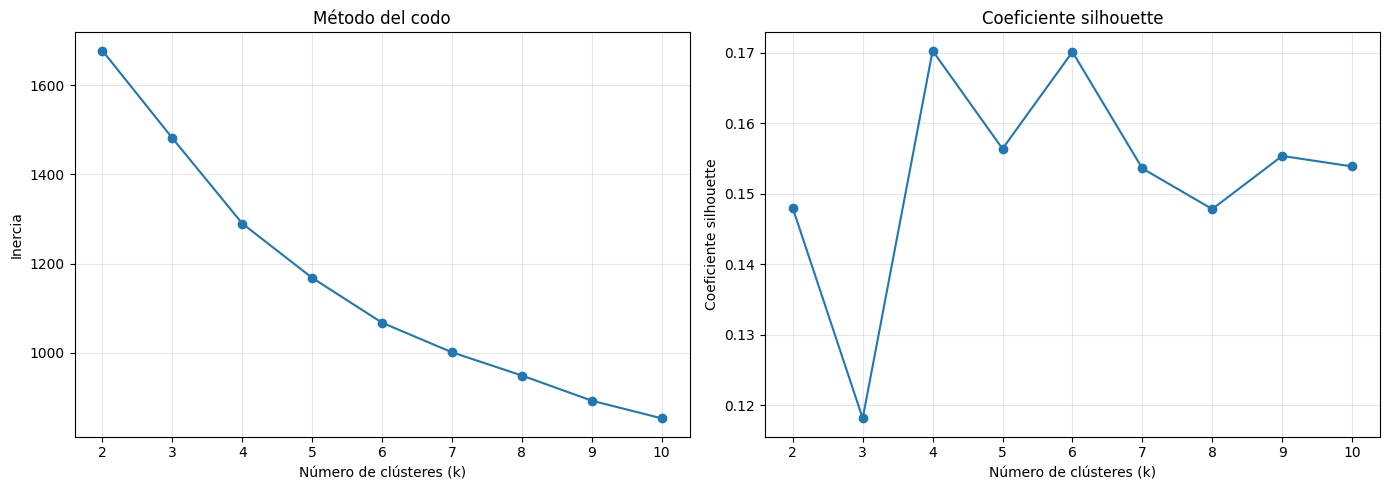

In [17]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(
    resultados_k_nuevo["k"],
    resultados_k_nuevo["inercia"],
    marker="o"
)
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clústeres (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_xticks(resultados_k_nuevo["k"])
axes[0].grid(True, alpha=0.3)

# Coeficiente silhouette
axes[1].plot(
    resultados_k_nuevo["k"],
    resultados_k_nuevo["silueta"],
    marker="o"
)
axes[1].set_title("Coeficiente silhouette")
axes[1].set_xlabel("Número de clústeres (k)")
axes[1].set_ylabel("Coeficiente silhouette")
axes[1].set_xticks(resultados_k_nuevo["k"])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **Seleccion de k 4, 5 y 6 para evaluacion**

In [20]:
from sklearn.cluster import KMeans
import pandas as pd

resultados_clustering = {}
resumen_tamanos = []

for k in [4,5,6]:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    etiquetas = modelo.fit_predict(X_nuevo_estandarizado)

    resultados_clustering[k] = {
        "modelo": modelo,
        "etiquetas": etiquetas
    }

    conteos = pd.Series(etiquetas).value_counts().sort_index()

    for cluster, cantidad in conteos.items():
        resumen_tamanos.append({
            "k": k,
            "cluster": cluster,
            "municipios": cantidad,
            "porcentaje": round(cantidad / len(etiquetas) * 100, 2)
        })

tabla_tamanos = pd.DataFrame(resumen_tamanos)
tabla_tamanos

,k,cluster,municipios,porcentaje
0,4,0,57,45.6
1,4,1,31,24.8
2,4,2,21,16.8
3,4,3,16,12.8
4,5,0,47,37.6
5,5,1,18,14.4
6,5,2,16,12.8
7,5,3,12,9.6
8,5,4,32,25.6
9,6,0,17,13.6


##### **Siluetas por cluster**

In [21]:
from sklearn.metrics import silhouette_samples

resultados_silueta = {}

for k in [4,5,6]:
    etiquetas = resultados_clustering[k]["etiquetas"]

    siluetas = silhouette_samples(
        X_nuevo_estandarizado,
        etiquetas
    )

    df_silueta = df_matriz_variables.copy()
    df_silueta["cluster"] = etiquetas
    df_silueta["silueta"] = siluetas

    resumen = (
        df_silueta.groupby("cluster")["silueta"]
        .agg(["count", "mean", "min", "max"])
        .round(3)
    )

    resultados_silueta[k] = df_silueta

    print(f"\nSilueta por clúster para k={k}")
    display(resumen)



Silueta por clúster para k=4


,count,mean,min,max
cluster,,,,
0,57,0.213,0.081,0.404
1,31,0.140,-0.008,0.335
2,21,0.079,-0.101,0.225
3,16,0.196,-0.008,0.392



Silueta por clúster para k=5


,count,mean,min,max
cluster,,,,
0,47,0.149,0.023,0.304
1,18,0.103,-0.081,0.246
2,16,0.151,-0.072,0.367
3,12,0.221,-0.060,0.416
4,32,0.176,0.027,0.304



Silueta por clúster para k=6


,count,mean,min,max
cluster,,,,
0,17,0.161,-0.036,0.266
1,48,0.141,-0.028,0.308
2,11,0.237,-0.028,0.427
3,2,0.198,0.095,0.302
4,32,0.182,0.041,0.314
5,15,0.196,-0.010,0.408


##### **Perfiles por cluster**

In [25]:
df_perfil_general = df_matriz_variables.drop(columns=['id_ubicacion', 'municipio'])
perfiles_clustering = {}

for k in [5]:
    df_perfil = df_perfil_general.copy()
    df_perfil["cluster"] = resultados_clustering[k]["etiquetas"]

    perfiles = (
        df_perfil
        .groupby("cluster")[df_perfil_general.columns]
        .mean()
        .round(2)
    )

    perfiles_clustering[k] = perfiles

    print(f"\nPERFILES PROMEDIO PARA k = {k}")
    display(perfiles)


PERFILES PROMEDIO PARA k = 5


,pct_amenazas,pct_delitos_sexuales,pct_homicidios,pct_hurto_motocicletas_automotores,pct_hurto_residencias_comerciales,pct_lesiones_personales,pct_violencia_intrafamiliar,tendencia_anual,pct_masculino,pct_femenino,pct_edad_adolescentes,pct_edad_menores,pct_edad_adultos,pct_sin_empleo_armas,pct_armas_contundentes,pct_arma_fuego,pct_arma_blanca,pct_llave_maestra,pct_acido
cluster,,,,,,,,,,,,,,,,,,,
0,8.75,10.16,8.67,4.64,7.79,38.61,21.38,2.73,47.00,45.92,5.32,3.48,89.93,32.86,27.34,11.17,10.63,0.62,8.04
1,15.32,14.45,7.34,5.80,8.36,31.12,17.61,0.98,42.51,49.45,4.91,3.69,90.91,42.05,15.94,7.98,12.73,0.85,0.76
2,11.65,11.34,21.19,6.60,6.63,25.80,16.80,4.90,52.09,41.47,5.10,3.46,90.55,33.06,19.47,23.38,7.82,1.00,5.01
3,4.26,5.52,2.54,15.85,13.37,32.84,25.61,141.25,44.71,42.71,3.45,2.06,93.36,39.23,24.92,8.44,8.95,4.54,1.47
4,8.11,9.79,6.54,8.28,12.79,36.82,17.67,9.07,46.41,42.07,3.75,3.00,91.46,38.82,24.61,9.17,7.74,1.35,6.87


##### **Composicion municipal de cada cluter**

In [26]:
# Asociar cada municipio con su clúster
df_municipios_cluster = df_matriz_variables[['municipio']].copy()
df_municipios_cluster['cluster'] = resultados_clustering[5]['etiquetas']

# Obtener y mostrar los municipios de cada clúster
municipios_por_cluster = (
    df_municipios_cluster
    .groupby('cluster')['municipio']
    .apply(list)
)

for cluster, municipios in municipios_por_cluster.items():
    print(f"\nCLÚSTER {cluster} ({len(municipios)} municipios)")
    print(", ".join(sorted(municipios)))


CLÚSTER 0 (47 municipios)
Abejorral, Alejandría, Amagá, Amalfi, Andes, Angelópolis, Angostura, Anorí, Anza, Argelia, Armenia, Barbosa, Belmira, Betulia, Campamento, Caramanta, Carolina, Cisneros, Cocorná, Concordia, Don Matías, Ebéjico, Fredonia, Frontino, Guadalupe, Gómez Plata, Heliconia, Hispania, Jardín, Jericó, Liborina, Nariño, Pueblorrico, Salgar, San Francisco, San José de la Montaña, San Roque, San Vicente, Santa Bárbara, Sonson, Tarso, Titiribí, Támesis, Urrao, Venecia, Yalí, Yarumal

CLÚSTER 1 (18 municipios)
Abriaquí, Apartadó, Arboletes, Caicedo, Carepa, Chigorodó, Dabeiba, Murindó, Mutatá, Nechí, Necoclí, Puerto Berrío, San Juan de Urabá, San Pedro de Urabá, Turbo, Uramita, Vigía del Fuerte, Yondó

CLÚSTER 2 (16 municipios)
Betania, Briceño, Ciudad Bolívar, Cáceres, El Bagre, Ituango, Olaya, Peque, Remedios, Sabanalarga, Segovia, Tarazá, Toledo, Valdivia, Vegachí, Zaragoza

CLÚSTER 3 (12 municipios)
Bello, Caldas, Copacabana, Envigado, Girardota, Guarne, Itagui, La Estre

In [129]:

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import pandas as pd

# Comparar distintas inicializaciones
resultados_estabilidad = []
etiquetas_base = None

for semilla in range(10):
    modelo = KMeans(
        n_clusters=4,
        random_state=semilla,
        n_init=20
    )

    etiquetas = modelo.fit_predict(X_nuevo_estandarizado)

    if etiquetas_base is None:
        etiquetas_base = etiquetas

    ari = adjusted_rand_score(etiquetas_base, etiquetas)

    resultados_estabilidad.append({
        "semilla": semilla,
        "inercia": modelo.inertia_,
        "ARI_vs_base": ari
    })

display(pd.DataFrame(resultados_estabilidad).round(4))

,semilla,inercia,ARI_vs_base
0,0,1404.5553,1.0000
1,1,1404.2485,0.4007
2,2,1403.2743,0.4166
3,3,1404.5553,1.0000
4,4,1405.1119,0.9337
5,5,1406.6272,0.4097
6,6,1403.7791,0.4156
7,7,1403.3836,0.3876
8,8,1403.2743,0.4166
9,9,1403.8503,0.4126


In [18]:

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score
)

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

# Matriz estandarizada de ESTE notebook
X = X_nuevo_estandarizado

N_SEMILLAS = 50
K = 5
N_INIT = 20

# En el notebook de 16 variables:
#nombre_modelo = "16_variables"

# En el notebook de 17 variables, reemplaza por:
nombre_modelo = "modelo_k5"

# ============================================================
# 2. EJECUTAR K-MEANS
# ============================================================

ejecuciones = []

for semilla in range(N_SEMILLAS):

    modelo = KMeans(
        n_clusters=K,
        random_state=semilla,
        n_init=N_INIT
    )

    etiquetas = modelo.fit_predict(X)
    sil_global = silhouette_score(X, etiquetas)
    sil_individual = silhouette_samples(X, etiquetas)

    ejecuciones.append({
        "semilla": semilla,
        "inercia": modelo.inertia_,
        "silueta_global": sil_global,
        "etiquetas": etiquetas.copy(),
        "silueta_individual": sil_individual
    })

# Solución de referencia: menor inercia
mejor = min(ejecuciones, key=lambda r: r["inercia"])
etiquetas_ref = mejor["etiquetas"]

# ============================================================
# 3. HOJA 1: EJECUCIONES
# ============================================================

df_ejecuciones = pd.DataFrame([
    {
        "semilla": e["semilla"],
        "inercia": e["inercia"],
        "silueta_global": e["silueta_global"],
        "ARI_vs_mejor_inercia": adjusted_rand_score(
            etiquetas_ref, e["etiquetas"]
        )
    }
    for e in ejecuciones
])

# ============================================================
# 4. HOJA 2: RESUMEN ESTADÍSTICO
# ============================================================

df_resumen = (
    df_ejecuciones[
        ["inercia", "silueta_global", "ARI_vs_mejor_inercia"]
    ]
    .agg(["min", "mean", "median", "max", "std"])
    .rename_axis("estadistico")
    .reset_index()
)

# ============================================================
# 5. HOJA 3: ESTABILIDAD ENTRE PARES
# ============================================================

ari_pares = []

for i in range(len(ejecuciones)):
    for j in range(i + 1, len(ejecuciones)):
        ari_pares.append(
            adjusted_rand_score(
                ejecuciones[i]["etiquetas"],
                ejecuciones[j]["etiquetas"]
            )
        )

df_estabilidad = pd.DataFrame([{
    "numero_pares": len(ari_pares),
    "ARI_media": np.mean(ari_pares),
    "ARI_mediana": np.median(ari_pares),
    "ARI_minimo": np.min(ari_pares),
    "ARI_maximo": np.max(ari_pares),
    "ARI_desviacion": np.std(ari_pares)
}])

# ============================================================
# 6. HOJA 4: SILUETA POR CLÚSTER
# ============================================================

df_silueta_cluster = pd.DataFrame({
    "cluster": etiquetas_ref,
    "silueta": mejor["silueta_individual"]
})

df_silueta_cluster = (
    df_silueta_cluster.groupby("cluster")
    .agg(
        municipios=("silueta", "size"),
        silueta_media=("silueta", "mean"),
        silueta_min=("silueta", "min"),
        silueta_max=("silueta", "max"),
        silueta_desviacion=("silueta", "std")
    )
    .reset_index()
)

df_silueta_cluster["porcentaje_municipios"] = (
    100 * df_silueta_cluster["municipios"] / len(X)
)

# ============================================================
# 7. HOJA 5: TAMAÑOS DE CLÚSTERES
# ============================================================

df_tamanos = (
    pd.Series(etiquetas_ref, name="cluster")
    .value_counts()
    .sort_index()
    .rename("municipios")
    .reset_index()
)

df_tamanos["porcentaje_municipios"] = (
    100 * df_tamanos["municipios"] / len(X)
)

# ============================================================
# 8. EXPORTAR A UN EXCEL CON CINCO HOJAS
# ============================================================

nombre_archivo = f"resultados_{nombre_modelo}_k4.xlsx"

with pd.ExcelWriter(nombre_archivo, engine="openpyxl") as writer:

    df_ejecuciones.to_excel(
        writer, sheet_name="Ejecuciones", index=False
    )

    df_resumen.to_excel(
        writer, sheet_name="Resumen", index=False
    )

    df_estabilidad.to_excel(
        writer, sheet_name="Estabilidad_ARI", index=False
    )

    df_silueta_cluster.to_excel(
        writer, sheet_name="Silueta_clusters", index=False
    )

    df_tamanos.to_excel(
        writer, sheet_name="Tamanos_clusters", index=False
    )

    # Ajustar automáticamente el ancho de las columnas
    for hoja in writer.sheets.values():
        hoja.freeze_panes = "A2"
        hoja.auto_filter.ref = hoja.dimensions

        for columna in hoja.columns:
            ancho = max(
                len(str(celda.value or "")) for celda in columna
            )
            hoja.column_dimensions[
                columna[0].column_letter
            ].width = min(ancho + 2, 30)

print(f"Archivo generado: {nombre_archivo}")
print(f"Semilla de referencia: {mejor['semilla']}")
print(f"Inercia: {mejor['inercia']:.4f}")
print(f"Silueta: {mejor['silueta_global']:.4f}")
print(f"ARI medio entre pares: {np.mean(ari_pares):.4f}")

Archivo generado: resultados_modelo_k5_k4.xlsx
Semilla de referencia: 6
Inercia: 1167.6274
Silueta: 0.1547
ARI medio entre pares: 0.8500


In [135]:

import pandas as pd
import numpy as np

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

# Matriz con los indicadores originales, ANTES de estandarizar.
# Debe tener una fila por municipio y los nombres de variables.
X_original_df = pd.DataFrame(df_matriz_variables).copy()

# Si los nombres de los municipios están en una columna
# de tu DataFrame original, indica aquí su nombre.
# Ejemplo: columna_municipio = "municipio"
columna_municipio = "municipio"

# Etiquetas de la solución seleccionada de K-Means
etiquetas_finales = mejor["etiquetas"]

if len(X_original_df) != len(etiquetas_finales):
    raise ValueError(
        "La matriz original y las etiquetas tienen distinto número de filas."
    )

# ============================================================
# 2. IDENTIFICAR LOS NOMBRES DE LOS MUNICIPIOS
# ============================================================

if columna_municipio in X_original_df.columns:
    municipios = X_original_df[columna_municipio].astype(str).reset_index(drop=True)
    indicadores = X_original_df.drop(columns=[columna_municipio])
else:
    # Si el nombre está en el índice, usarlo.
    municipios = pd.Series(
        X_original_df.index.astype(str),
        name="municipio"
    ).reset_index(drop=True)

    indicadores = X_original_df.copy()

# Conservar solamente las variables numéricas
indicadores = indicadores.select_dtypes(include="number")

if indicadores.shape[1] == 0:
    raise ValueError(
        "No se encontraron indicadores numéricos en X_original."
    )

# Comprobar valores faltantes e infinitos
if not np.isfinite(indicadores.to_numpy(dtype=float)).all():
    raise ValueError(
        "Hay valores faltantes o infinitos en los indicadores originales."
    )

# ============================================================
# 3. TABLA DE PERFILES POR CLÚSTER
# ============================================================

datos = indicadores.copy()
datos["cluster"] = etiquetas_finales

# Filas = variables; columnas = clústeres
tabla_perfiles = datos.groupby("cluster").mean().T

tabla_perfiles.index.name = "variable"
tabla_perfiles.columns = [
    f"cluster_{c}" for c in tabla_perfiles.columns
]

tabla_perfiles = tabla_perfiles.reset_index()

# ============================================================
# 4. TAMAÑO DE LOS CLÚSTERES
# ============================================================

tabla_tamanos = (
    pd.Series(etiquetas_finales, name="cluster")
    .value_counts()
    .sort_index()
    .rename("municipios")
    .reset_index()
)

tabla_tamanos["porcentaje"] = (
    tabla_tamanos["municipios"] / len(etiquetas_finales) * 100
)

# ============================================================
# 5. ASIGNACIÓN DE MUNICIPIOS
# ============================================================

tabla_asignaciones = pd.DataFrame({
    "municipio": municipios,
    "cluster": etiquetas_finales
})

# ============================================================
# 6. EXPORTAR A EXCEL
# ============================================================

nombre_archivo = "perfiles_clusters_17_variables.xlsx"

with pd.ExcelWriter(nombre_archivo, engine="openpyxl") as writer:

    tabla_perfiles.to_excel(
        writer,
        sheet_name="Perfiles_clusters",
        index=False
    )

    tabla_tamanos.to_excel(
        writer,
        sheet_name="Tamanos_clusters",
        index=False
    )

    tabla_asignaciones.to_excel(
        writer,
        sheet_name="Asignacion_municipios",
        index=False
    )

    # Ajustar anchos y fijar encabezados
    for hoja in writer.sheets.values():
        hoja.freeze_panes = "A2"
        hoja.auto_filter.ref = hoja.dimensions

        for columna in hoja.columns:
            ancho = max(
                len(str(celda.value or "")) for celda in columna
            )
            hoja.column_dimensions[
                columna[0].column_letter
            ].width = min(ancho + 2, 35)

print(f"Archivo exportado: {nombre_archivo}")

print("\nPERFILES POR CLÚSTER")
display(tabla_perfiles.round(2))

print("\nTAMAÑO DE LOS CLÚSTERES")
display(tabla_tamanos.round(2))

print("\nASIGNACIÓN DE MUNICIPIOS")
display(tabla_asignaciones.head())

Archivo exportado: perfiles_clusters_17_variables.xlsx

PERFILES POR CLÚSTER


,variable,cluster_0,cluster_1,cluster_2,cluster_3
0,id_ubicacion,65.39,59.72,60.26,75.89
1,total_afectaciones,2197.56,1071.91,15596.55,1131.44
2,desviacion_anual,40.83,29.79,296.52,32.57
3,pct_amenazas,15.32,8.75,6.09,11.78
4,pct_delitos_sexuales,14.45,10.01,8.13,11.43
5,pct_homicidios,7.34,8.34,4.62,19.96
6,pct_hurto_motocicletas_automotores,5.80,4.90,11.84,7.06
7,pct_hurto_residencias_comerciales,8.36,8.40,13.95,6.79
8,pct_lesiones_personales,31.12,38.74,34.67,26.56
9,pct_violencia_intrafamiliar,17.61,20.85,20.70,16.42



TAMAÑO DE LOS CLÚSTERES


,cluster,municipios,porcentaje
0,0,18,14.4
1,1,58,46.4
2,2,31,24.8
3,3,18,14.4



ASIGNACIÓN DE MUNICIPIOS


,municipio,cluster
0,Abejorral,1
1,Abriaquí,0
2,Alejandría,1
3,Amagá,1
4,Amalfi,1


In [134]:

import pandas as pd
import numpy as np

# 1. Copiar la matriz original de indicadores
perfiles = pd.DataFrame(df_matriz_variables).copy()

# 2. Conservar únicamente las columnas numéricas
perfiles = perfiles.select_dtypes(include="number")

# 3. Asignar los clústeres de la solución seleccionada
perfiles["cluster"] = mejor["etiquetas"]

# 4. Calcular los promedios de los indicadores por clúster
tabla_perfiles = perfiles.groupby("cluster").mean().T

tabla_perfiles.columns = [
    f"cluster_{c}" for c in tabla_perfiles.columns
]

print("PROMEDIOS DE LOS INDICADORES POR CLÚSTER")
display(tabla_perfiles.round(2))

# 5. Calcular la cantidad y proporción de municipios
tabla_tamanos = (
    perfiles["cluster"]
    .value_counts()
    .sort_index()
    .rename("municipios")
    .to_frame()
)

tabla_tamanos["porcentaje"] = (
    tabla_tamanos["municipios"] / len(perfiles) * 100
)

print("TAMAÑO DE LOS CLÚSTERES")
display(tabla_tamanos.round(2))

PROMEDIOS DE LOS INDICADORES POR CLÚSTER


,cluster_0,cluster_1,cluster_2,cluster_3
id_ubicacion,65.39,59.72,60.26,75.89
total_afectaciones,2197.56,1071.91,15596.55,1131.44
desviacion_anual,40.83,29.79,296.52,32.57
pct_amenazas,15.32,8.75,6.09,11.78
pct_delitos_sexuales,14.45,10.01,8.13,11.43
pct_homicidios,7.34,8.34,4.62,19.96
pct_hurto_motocicletas_automotores,5.80,4.90,11.84,7.06
pct_hurto_residencias_comerciales,8.36,8.40,13.95,6.79
pct_lesiones_personales,31.12,38.74,34.67,26.56
pct_violencia_intrafamiliar,17.61,20.85,20.70,16.42


TAMAÑO DE LOS CLÚSTERES


,municipios,porcentaje
cluster,,
0,18,14.4
1,58,46.4
2,31,24.8
3,18,14.4
